# Лабораторная работа 2

**Тема:** обработка признаков: масштабирование, выбросы, нестандартные признаки и отбор признаков.

Для основной части используем встроенный датасет Wine из `sklearn`, чтобы ноутбук запускался без скачивания данных.

In [1]:
import importlib.util
import subprocess
import sys


def ensure(package, import_name=None):
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

for package, import_name in [
    ('numpy', 'numpy'),
    ('pandas', 'pandas'),
    ('matplotlib', 'matplotlib'),
    ('scikit-learn', 'sklearn'),
]:
    ensure(package, import_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import RFE, SelectFromModel, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

pd.set_option('display.max_columns', 30)
RANDOM_STATE = 42

In [2]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()
df['sample_date'] = pd.date_range('2024-01-03', periods=len(df), freq='7D')
df['taster_note'] = np.select(
    [df['target'].eq(0), df['target'].eq(1), df['target'].eq(2)],
    ['mineral dry bright', 'soft fruit balanced', 'dense spicy tannin'],
)

X_numeric = df[wine.feature_names]
y = df['target']

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,sample_date,taster_note
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,2024-01-03,mineral dry bright
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,2024-01-10,mineral dry bright
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,2024-01-17,mineral dry bright
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,2024-01-24,mineral dry bright
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,2024-01-31,mineral dry bright


Покажем три способа масштабирования на одних и тех же числовых признаках.

In [3]:
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

scaled_stats = []
scaled_examples = {}
for name, scaler in scalers.items():
    scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=wine.feature_names)
    scaled_examples[name] = scaled
    scaled_stats.append({
        'method': name,
        'mean(alcohol)': scaled['alcohol'].mean(),
        'std(alcohol)': scaled['alcohol'].std(),
        'min(alcohol)': scaled['alcohol'].min(),
        'max(alcohol)': scaled['alcohol'].max(),
    })

pd.DataFrame(scaled_stats).round(3)

,method,mean(alcohol),std(alcohol),min(alcohol),max(alcohol)
0,StandardScaler,-0.000,1.003,-2.434,2.260
1,MinMaxScaler,0.519,0.214,0.000,1.000
2,RobustScaler,-0.038,0.617,-1.536,1.354


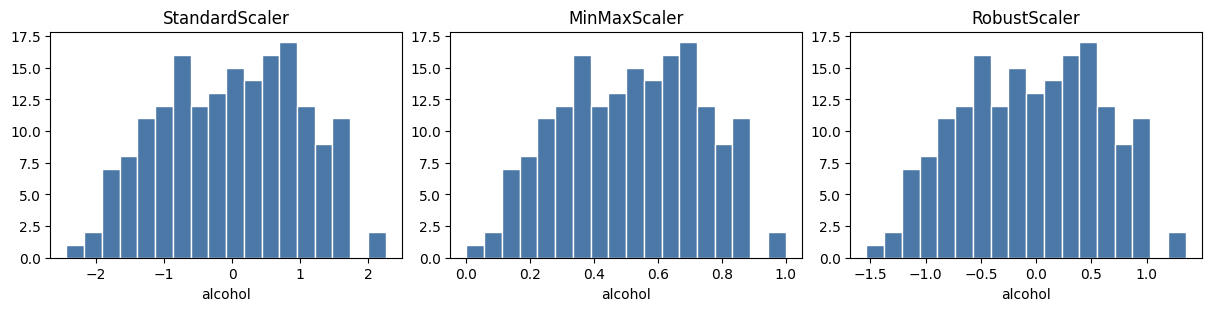

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
for ax, (name, scaled) in zip(axes, scaled_examples.items()):
    ax.hist(scaled['alcohol'], bins=18, color='#4c78a8', edgecolor='white')
    ax.set_title(name)
    ax.set_xlabel('alcohol')
plt.show()

Для удаления выбросов используем IQR-фильтр, а для замены — ограничение значений по IQR-границам.

In [5]:
def iqr_bounds(series, coef=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - coef * iqr, q3 + coef * iqr

remove_col = 'proline'
lo, hi = iqr_bounds(df[remove_col])
mask = df[remove_col].between(lo, hi)
df_without_outliers = df.loc[mask].copy()

replace_col = 'color_intensity'
clip_lo, clip_hi = iqr_bounds(df[replace_col])
df_replaced = df.copy()
df_replaced[replace_col] = df_replaced[replace_col].clip(clip_lo, clip_hi)

pd.DataFrame({
    'operation': ['remove outliers', 'replace outliers'],
    'feature': [remove_col, replace_col],
    'rows_before': [len(df), len(df)],
    'rows_after': [len(df_without_outliers), len(df_replaced)],
    'lower_bound': [lo, clip_lo],
    'upper_bound': [hi, clip_hi],
}).round(2)

,operation,feature,rows_before,rows_after,lower_bound,upper_bound
0,remove outliers,proline,178,178,-226.25,1711.75
1,replace outliers,color_intensity,178,178,-1.25,10.67


/var/folders/1k/4ny8djps77s6s64cbns_kzcw0000gn/T/ipykernel_75919/1129084445.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df[replace_col], df_replaced[replace_col]], labels=['before', 'after'])
/var/folders/1k/4ny8djps77s6s64cbns_kzcw0000gn/T/ipykernel_75919/1129084445.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[remove_col], df_without_outliers[remove_col]], labels=['before', 'after'])


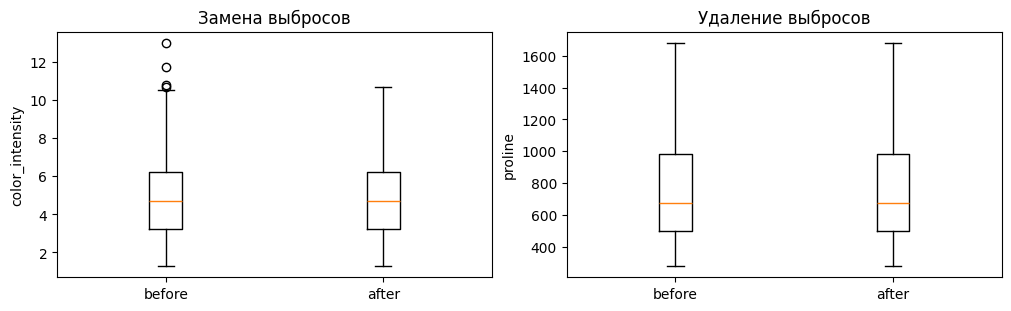

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
axes[0].boxplot([df[replace_col], df_replaced[replace_col]], labels=['before', 'after'])
axes[0].set_title('Замена выбросов')
axes[0].set_ylabel(replace_col)
axes[1].boxplot([df[remove_col], df_without_outliers[remove_col]], labels=['before', 'after'])
axes[1].set_title('Удаление выбросов')
axes[1].set_ylabel(remove_col)
plt.show()

Нестандартные признаки: из даты извлекаем календарные признаки, а текстовое описание превращаем в TF-IDF признаки.

In [7]:
datetime_features = pd.DataFrame({
    'sample_month': df['sample_date'].dt.month,
    'sample_dayofyear': df['sample_date'].dt.dayofyear,
    'sample_weekday': df['sample_date'].dt.weekday,
})

vectorizer = TfidfVectorizer(max_features=6)
text_features = pd.DataFrame(
    vectorizer.fit_transform(df['taster_note']).toarray(),
    columns=[f'tfidf_{term}' for term in vectorizer.get_feature_names_out()],
)

pd.concat([df[['sample_date', 'taster_note']].head(), datetime_features.head(), text_features.head()], axis=1)

,sample_date,taster_note,sample_month,sample_dayofyear,sample_weekday,tfidf_balanced,tfidf_bright,tfidf_dry,tfidf_fruit,tfidf_mineral,tfidf_soft
0,2024-01-03,mineral dry bright,1,3,2,0.0,0.57735,0.57735,0.0,0.57735,0.0
1,2024-01-10,mineral dry bright,1,10,2,0.0,0.57735,0.57735,0.0,0.57735,0.0
2,2024-01-17,mineral dry bright,1,17,2,0.0,0.57735,0.57735,0.0,0.57735,0.0
3,2024-01-24,mineral dry bright,1,24,2,0.0,0.57735,0.57735,0.0,0.57735,0.0
4,2024-01-31,mineral dry bright,1,31,2,0.0,0.57735,0.57735,0.0,0.57735,0.0


Для отбора признаков сравним фильтрационный метод, метод обертывания и embedded-подход.

In [8]:
X = df[wine.feature_names]
y = df['target']
feature_names = np.array(wine.feature_names)
X_scaled = StandardScaler().fit_transform(X)

filter_selector = SelectKBest(score_func=f_classif, k=5).fit(X, y)
filter_features = feature_names[filter_selector.get_support()]

wrapper_model = LogisticRegression(max_iter=5000, solver='lbfgs', random_state=RANDOM_STATE)
wrapper_selector = RFE(wrapper_model, n_features_to_select=5).fit(X_scaled, y)
wrapper_features = feature_names[wrapper_selector.get_support()]

embedded_model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
embedded_selector = SelectFromModel(embedded_model, threshold='median').fit(X, y)
embedded_features = feature_names[embedded_selector.get_support()]

pd.DataFrame({
    'method_group': ['filter', 'wrapper', 'embedded'],
    'method': ['SelectKBest(f_classif)', 'RFE(LogisticRegression)', 'SelectFromModel(RandomForest)'],
    'selected_features': [', '.join(filter_features), ', '.join(wrapper_features), ', '.join(embedded_features)],
})

,method_group,method,selected_features
0,filter,SelectKBest(f_classif),"alcohol, flavanoids, color_intensity, od280/od..."
1,wrapper,RFE(LogisticRegression),"alcohol, flavanoids, color_intensity, hue, pro..."
2,embedded,SelectFromModel(RandomForest),"alcohol, total_phenols, flavanoids, color_inte..."


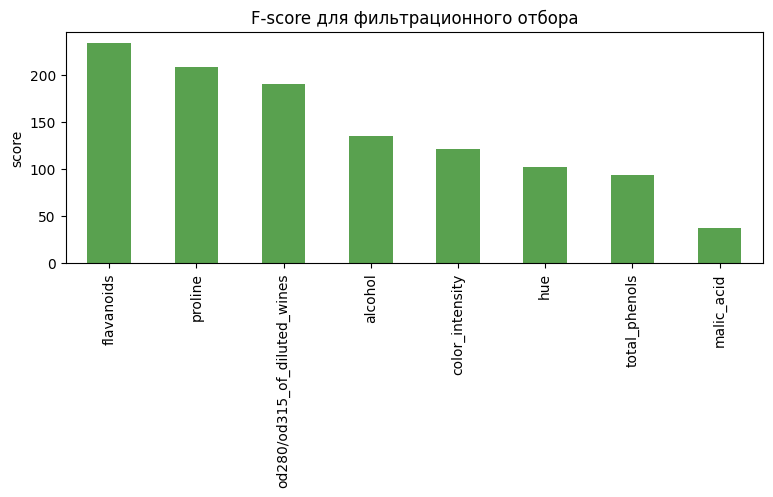

In [9]:
scores = pd.Series(filter_selector.scores_, index=feature_names).sort_values(ascending=False)
scores.head(8).plot(kind='bar', figsize=(9, 3), color='#59a14f')
plt.title('F-score для фильтрационного отбора')
plt.ylabel('score')
plt.show()